In [1]:
!pip install xgboost

  Using cached xgboost-3.1.1-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.1-py3-none-win_amd64.whl (72.0 MB)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve, 
    auc
)
%matplotlib inline
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('bank+marketing/bank/bank-full.csv', sep=';')

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
df['y_numeric'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [11]:
X = df.drop(['y', 'y_numeric'], axis=1)
y = df['y_numeric']

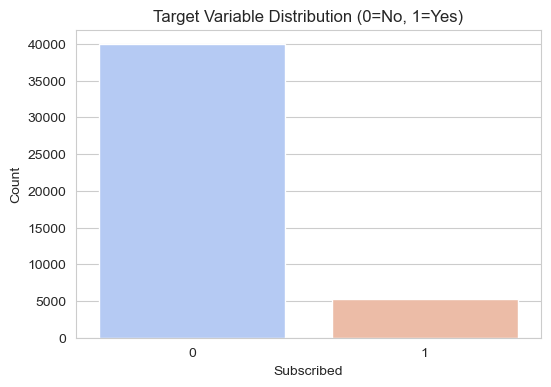

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='y_numeric', data=df, palette='coolwarm')
plt.title('Target Variable Distribution (0=No, 1=Yes)')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.savefig('target_imbalance.png', bbox_inches='tight')
plt.show()

In [14]:
print(f"Subscribers: {df['y_numeric'].sum()}")
print(f"Non-Subscribers: {len(df) - df['y_numeric'].sum()}")
print(f"Imbalance Ratio: {df['y_numeric'].mean():.1%}")

Subscribers: 5289
Non-Subscribers: 39922
Imbalance Ratio: 11.7%


In [17]:
job_rate = df.groupby('job')['y_numeric'].mean().sort_values(ascending=False)

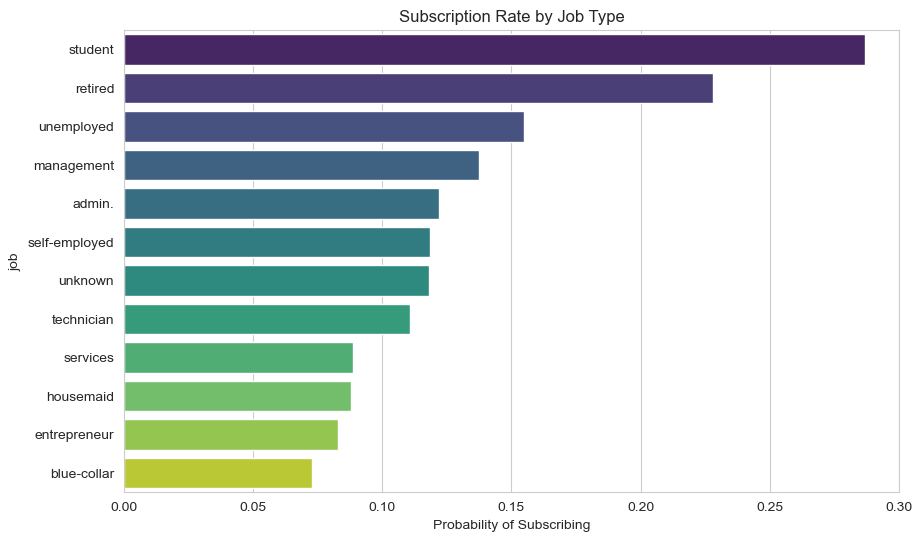

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x=job_rate.values, y=job_rate.index, palette='viridis')
plt.title('Subscription Rate by Job Type')
plt.xlabel('Probability of Subscribing')
plt.xlim(0, 0.3)
plt.savefig('job_rates.png', bbox_inches='tight')
plt.show()

In [21]:
X = df.drop(['y', 'y_numeric'], axis=1)
y = df['y_numeric']

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
print(f"Training Rows: {X_train.shape[0]}")
print(f"Testing Rows: {X_test.shape[0]}")

Training Rows: 31647
Testing Rows: 13564


In [29]:
from sklearn.model_selection import RandomizedSearchCV

In [31]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 800],   
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12],               
    'min_child_weight': [1, 3, 5, 7, 10],                  

    'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5],                  

    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],                
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],         

    'scale_pos_weight': [1, 5, 8, 10, 12, 15, 20]          
}

In [33]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [35]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=200,
    scoring='f1',
    cv=5,
    verbose=3,
    random_state=42,
    n_jobs=-1
)

In [37]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5],
                                        'learning_rate': [0.005, 0.01, 0.02,
                                                          0.05, 0.1, 0.15, 0.2,
                                                          0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 10, 12],
                                        'min_child_weight': [1, 3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 800],
                                        'scale_pos_weight': [1, 5, 8, 10, 12,
                                                             15, 20],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1', verbose=3)

In [38]:
print(f"Validation Score: {random_search.best_score_:.4f}")
print("Parameters we should use:")
print(random_search.best_params_)

Validation Score: 0.6234
Parameters we should use:
{'subsample': 0.6, 'scale_pos_weight': 5, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.02, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [83]:
model = random_search.best_estimator_

In [95]:
y_pred = model.predict_proba(X_test)[:, 1]

In [97]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93     11966
           1       0.52      0.80      0.63      1598

    accuracy                           0.89     13564
   macro avg       0.74      0.85      0.78     13564
weighted avg       0.92      0.89      0.90     13564



In [99]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

In [103]:
joblib.dump(model, 'xgboost_bank_model.pkl')
joblib.dump(X.columns, 'model_features.pkl')
print("Model Saved")

Model Saved


In [105]:
y_pred = model.predict_proba(X_test)[:, 1]

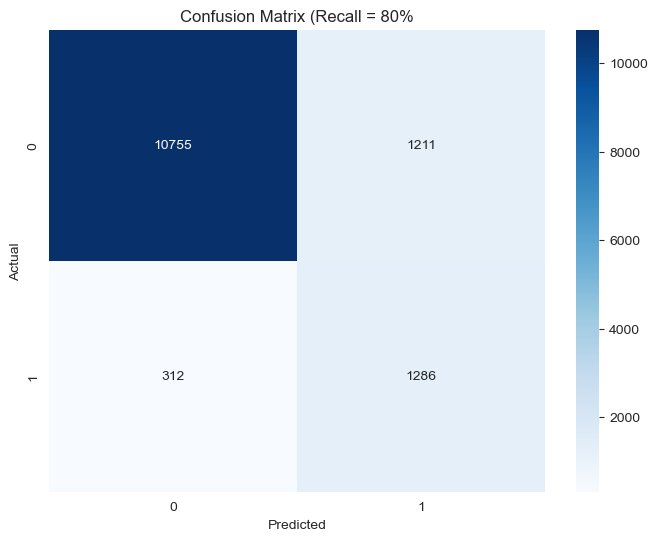

In [111]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Recall = 80%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

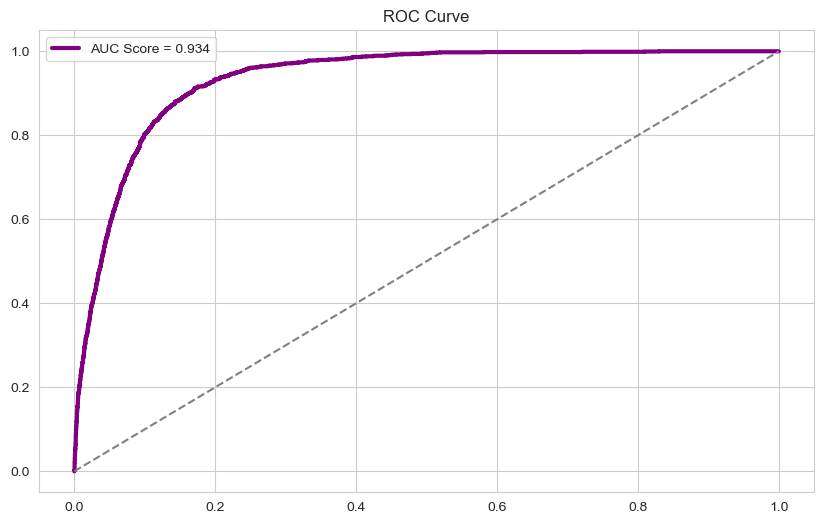

In [115]:
auc_score = roc_auc_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"AUC Score = {auc_score:.3f}", color='purple', lw=3)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

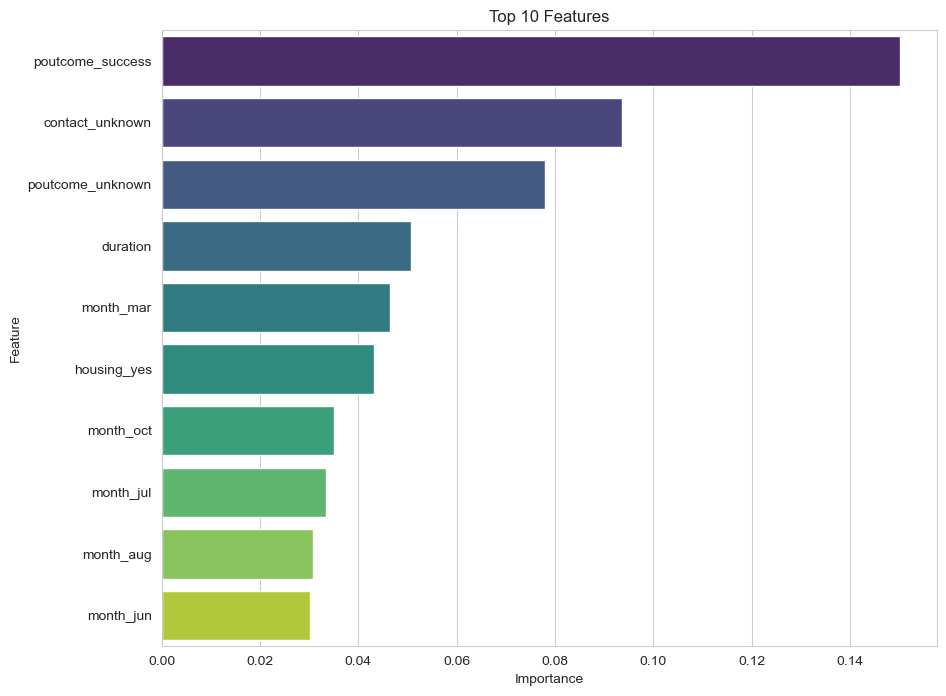

Images Saved


In [117]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Top 10 Features')
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("Images Saved")